/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [23:03:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- MODEL COMPARISON TABLE ---
              Model   Metric  Score
Logistic Regression Accuracy 0.7989
      Random Forest Accuracy 0.8324
            XGBoost Accuracy 0.8101


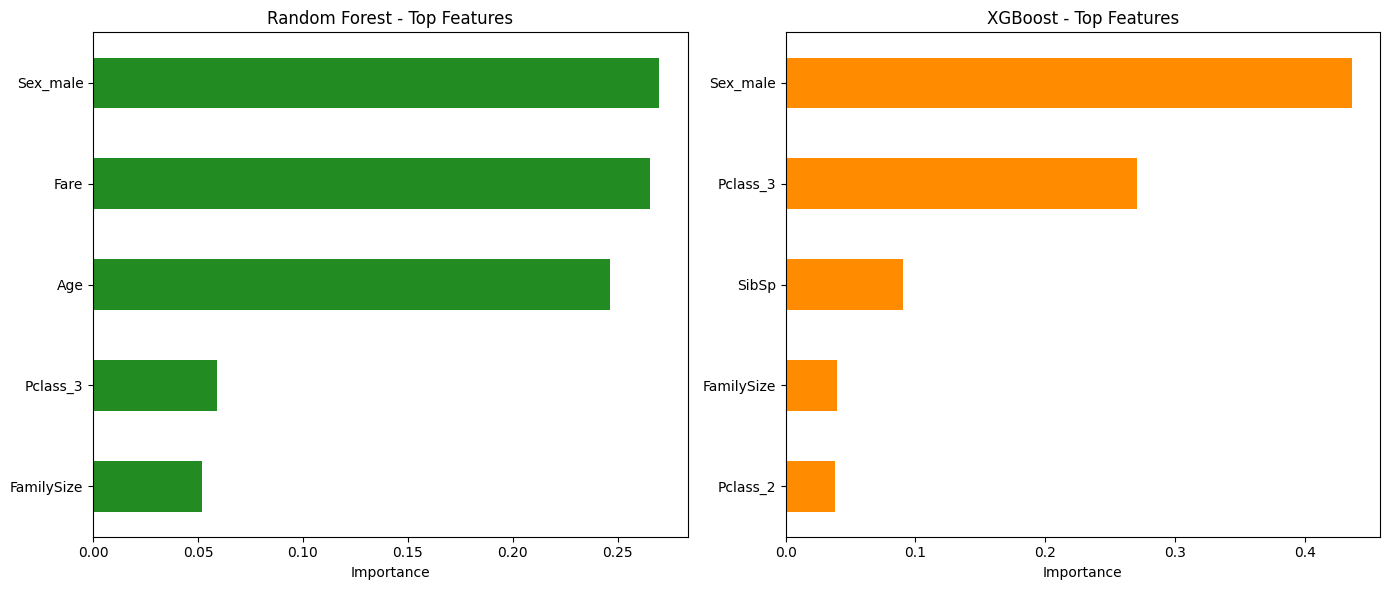

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# 1. Load and prep the Titanic dataset
df = pd.read_csv('titanic.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

X = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis=1)
y = df['Survived']
X = pd.get_dummies(X, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Models: Logistic Regression, Random Forest, and XGBoost
lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# 3. Evaluate Performance
lr_acc = accuracy_score(y_test, lr.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

print("--- MODEL COMPARISON TABLE ---")
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Metric": ["Accuracy", "Accuracy", "Accuracy"],
    "Score": [lr_acc, rf_acc, xgb_acc]
}).round(4)
print(comparison_table.to_string(index=False))

# 4. Plot Feature Importances for Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest Importances
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
rf_importances.tail(5).plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title("Random Forest - Top Features")
axes[0].set_xlabel("Importance")

# XGBoost Importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()
xgb_importances.tail(5).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("XGBoost - Top Features")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

**How Random Forest and XGBoost Differ:**

Random Forest uses Bagging (Bootstrap Aggregating), training multiple decision trees independently and in parallel on randomized subsets of data, then averaging their votes to reduce variance. XGBoost uses Boosting, building trees sequentially where each new tree specifically tries to correct the errors and residuals left behind by the previous trees. While Random Forest builds deep trees independently, XGBoost constructs shallow trees step-by-step with strict regularization to systematically optimize performance.